In [1]:
# ===== Step 1: Load and Explore Dataset =====

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('material.csv', encoding='ascii')

In [2]:
# Step 2: data profiling (missing values, uniques, dtypes, stats)
import pandas as pd
import numpy as np

# Assumes df is loaded from Step 1
print("Shape:", df.shape)

# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(3)
miss_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
print("\nMissing values (per column):\n", miss_df)

# Duplicates
dup_count = df.duplicated().sum()
print("\nDuplicate rows:", dup_count)

# Data types & memory
print("\nDtypes:\n", df.dtypes)
print("\nMemory usage (MB):", df.memory_usage(deep=True).sum() / 1024**2)

# Unique counts and top values for object columns
unique_counts = df.nunique(dropna=False).sort_values(ascending=False)
print("\nUnique value counts (all columns):\n", unique_counts)

obj_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
for c in obj_cols:
    print(f"\nTop values for {c} (up to 8):")
    print(df[c].value_counts(dropna=False).head(8))

# Numeric descriptive statistics
num_df = df.select_dtypes(include=[np.number])
print("\nNumeric summary (describe):\n", num_df.describe().T)

# Save a concise summary CSV
summary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(dropna=False).values,
    "n_missing": df.isnull().sum().values,
    "pct_missing": (df.isnull().sum().values / len(df) * 100).round(3),
    "first_5_values": [", ".join(map(str, df[c].dropna().unique()[:5])) if df[c].dropna().shape[0]>0 else "[]" for c in df.columns]
})
summary.to_csv("dataset_summary.csv", index=False)
print("\nSaved dataset_summary.csv")

Shape: (1552, 8)

Missing values (per column):
           missing_count  missing_pct
Material              0          0.0
Su                    0          0.0
Sy                    0          0.0
E                     0          0.0
G                     0          0.0
mu                    0          0.0
Ro                    0          0.0
Use                   0          0.0

Duplicate rows: 4

Dtypes:
 Material     object
Su            int64
Sy            int64
E             int64
G             int64
mu          float64
Ro            int64
Use            bool
dtype: object

Memory usage (MB): 0.18783950805664062

Unique value counts (all columns):
 Material    1460
Su           309
Sy           286
E             43
Ro            35
G             33
mu            11
Use            2
dtype: int64

Top values for Material (up to 8):
Material
ISO Grey cast iron           5
JIS Grey cast iron           5
NF Grey cast iron            5
BS Grey cast iron            5
NF Nodular cast iron 

In [3]:
# Step 3: Suggest features and targets + compute correlation with target(s)
import numpy as np

# Candidate targets (you can change these)
suggested_targets = ['Su', 'Sy']   # common mechanical property targets
available_targets = [t for t in suggested_targets if t in df.columns]
if not available_targets:
    raise ValueError("Suggested targets not found in dataset columns. Inspect df.columns and select appropriate target.")

print("Available suggested targets:", available_targets)

# Candidate numeric features (exclude target columns)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric columns found:", num_cols)

# Build feature list by excluding targets and obvious identifier-like columns
features = [c for c in num_cols if c not in available_targets]
print("Candidate features (numeric):", features)

# Correlation with primary target
primary_target = available_targets[0]
corrs = df[features + [primary_target]].corr()[primary_target].drop(primary_target).abs().sort_values(ascending=False)
print(f"\nAbsolute correlations with target '{primary_target}':\n", corrs)

# If Material column exists, note as categorical feature
categorical_cols = df.select_dtypes(include=['object','category','bool']).columns.tolist()
print("\nCategorical columns:", categorical_cols)

# Recommendation summary
print("\nRecommendation:")
print(f" - Primary target: {primary_target}")
print(f" - Numeric features to consider: {features}")
print(f" - Categorical features to encode: {categorical_cols} (e.g., Material)")

Available suggested targets: ['Su', 'Sy']
Numeric columns found: ['Su', 'Sy', 'E', 'G', 'mu', 'Ro']
Candidate features (numeric): ['E', 'G', 'mu', 'Ro']

Absolute correlations with target 'Su':
 E     0.594348
Ro    0.407995
G     0.254508
mu    0.239663
Name: Su, dtype: float64

Categorical columns: ['Material', 'Use']

Recommendation:
 - Primary target: Su
 - Numeric features to consider: ['E', 'G', 'mu', 'Ro']
 - Categorical features to encode: ['Material', 'Use'] (e.g., Material)


In [4]:
# Step 4: anomaly checks for physical properties
import numpy as np

# Assumed plausible ranges (adjust if needed)
plausible = {
    'E': (1e4, 3e5),   # Young's modulus, plausible range in MPa (10 GPa - 300 GPa)
    'G': (5e3, 1.5e5), # shear modulus in MPa
    'Ro': (500, 30000) # density in kg/m^3 (broad)
}

for col, (low, high) in plausible.items():
    if col in df.columns:
        outliers = df[(df[col] < low) | (df[col] > high)]
        print(f"{col}: plausible [{low}..{high}] -> outlier count:", len(outliers))
        if len(outliers) > 0:
            print(outliers[[col, 'Material']].head(6).to_string(index=False))

# If any found, create a boolean flag column
for col in plausible:
    if col in df.columns:
        df[f'{col}_plausible'] = df[col].between(plausible[col][0], plausible[col][1])

# Save flagged rows if any
df[df[[f'{c}_plausible' for c in plausible if f'{c}_plausible' in df.columns]].any(axis=1)==False].to_csv("flagged_physical_outliers.csv", index=False)
print("\nSaved flagged_physical_outliers.csv (may be empty).")

E: plausible [10000.0..300000.0] -> outlier count: 0
G: plausible [5000.0..150000.0] -> outlier count: 51
     G                       Material
743000  ANSI Steel SAE 30201 annealed
743000  ANSI Steel SAE 30201 1/4-hard
743000  ANSI Steel SAE 30201 1/2-hard
743000  ANSI Steel SAE 30201 3/4-hard
743000 ANSI Steel SAE 30201 Full-hard
743000  ANSI Steel SAE 30202 annealed
Ro: plausible [500..30000] -> outlier count: 0

Saved flagged_physical_outliers.csv (may be empty).


In [5]:
# Step 5: preprocessing pipeline
import re
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 5.1: Create a material_family by regex heuristics (Steel, Al, Copper, Ti, Composite, Brass, Bronze, Polymer)
def infer_material_family(name):
    if not isinstance(name, str):
        return 'Unknown'
    name_l = name.lower()
    if 'steel' in name_l: return 'Steel'
    if 'alumin' in name_l or 'aluminium' in name_l or 'aluminum' in name_l: return 'Aluminium'
    if 'titan' in name_l: return 'Titanium'
    if 'copper' in name_l or 'cu' in name_l: return 'Copper'
    if 'brass' in name_l: return 'Brass'
    if 'composite' in name_l or 'carbon' in name_l or 'fiber' in name_l: return 'Composite'
    if 'poly' in name_l or 'pa ' in name_l or 'nylon' in name_l: return 'Polymer'
    return 'Other'

if 'Material' in df.columns:
    df['material_family'] = df['Material'].apply(infer_material_family)
    print("Material families created. Value counts:")
    print(df['material_family'].value_counts())

# 5.2: Frequency-based grouping for very rare Material names (top-K or freq threshold)
if 'Material' in df.columns:
    freq = df['Material'].value_counts(normalize=True)
    rare_threshold = 0.005  # materials whose share < 0.5% become 'Other'
    rare_names = freq[freq < rare_threshold].index
    df['Material_grouped'] = df['Material'].where(~df['Material'].isin(rare_names), other='Other')
    print("\nMaterial grouping: unique after grouping:", df['Material_grouped'].nunique())

# 5.3: Prepare sklearn ColumnTransformer pipeline: numeric imputation + scaling, categorical encoding
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
# drop the target(s) if present from numeric_features - keep them aside
targets = [t for t in ['Su','Sy'] if t in df.columns]
numeric_features = [c for c in numeric_features if c not in targets]

categorical_features = []
if 'material_family' in df.columns:
    categorical_features.append('material_family')
if 'Material_grouped' in df.columns:
    categorical_features.append('Material_grouped')
if 'Use' in df.columns and df['Use'].dtype == 'bool':
    # convert boolean to int
    df['Use'] = df['Use'].astype(int)
    if 'Use' not in numeric_features:
        numeric_features.append('Use')

print("\nNumeric features for pipeline:", numeric_features)
print("Categorical features for pipeline:", categorical_features)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
], remainder='drop', verbose_feature_names_out=False)

# Fit transform to create processed array and a column list
X_processed = preprocessor.fit_transform(df)
# Build column names for transformed features
num_out = numeric_features
cat_out = list(preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)) if categorical_features else []
transformed_cols = num_out + cat_out
proc_df = pd.DataFrame(X_processed, columns=transformed_cols)
# Re-attach target(s)
for t in targets:
    proc_df[t] = df[t].values

proc_df.to_csv("material_processed_for_modeling.csv", index=False)
print("\nSaved processed dataset -> material_processed_for_modeling.csv")

Material families created. Value counts:
material_family
Other        740
Steel        456
Aluminium    251
Copper        84
Brass         21
Name: count, dtype: int64

Material grouping: unique after grouping: 1

Numeric features for pipeline: ['E', 'G', 'mu', 'Ro', 'Use']
Categorical features for pipeline: ['material_family', 'Material_grouped']

Saved processed dataset -> material_processed_for_modeling.csv


C:\Users\kanakaraju\AppData\Roaming\Python\Python312\site-packages\sklearn\preprocessing\_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [6]:
# Step 6: publication-ready visualizations
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# We will plot: histograms for numeric columns, correlation heatmap, 3D scatter (E vs Su vs Ro)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Keep the sample columns to plot
plot_cols = [c for c in ['Su','Sy','E','G','mu','Ro'] if c in numeric_cols]

# Helper for saving with IEEE formatting
def save_fig(fig, filename, dpi=900):
    fig.tight_layout(pad=0.5)
    fig.savefig(filename, dpi=dpi, bbox_inches='tight')
    print("Saved:", filename)

# 6.1 Histograms (one per figure)
for col in plot_cols:
    fig, ax = plt.subplots(figsize=(6,4))
    ax.hist(df[col].dropna(), bins=30)
    ax.set_title(f"{col} distribution", fontweight='bold', fontsize=14)
    unit = ""
    if col in ['Su','Sy']: unit = " (MPa)"
    if col in ['E','G']: unit = " (MPa)"
    if col == 'Ro': unit = " (kg·m$^{-3}$)"
    if col == 'mu': unit = " (unitless)"
    ax.set_xlabel(f"{col}{unit}", fontweight='bold', fontsize=12)
    ax.set_ylabel("Frequency", fontweight='bold', fontsize=12)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    save_fig(fig, f"hist_{col}.png", dpi=900)
    plt.close(fig)

# 6.2 Correlation heatmap (numerical)
corr = df[plot_cols].corr()
fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", ax=ax, cbar_kws={'shrink':0.7}, square=False)
ax.set_title("Correlation matrix (selected numeric properties)", fontweight='bold', fontsize=14)
save_fig(fig, "correlation_heatmap.png", dpi=900)
plt.close(fig)

# 6.3 3D scatter: E vs Su vs Ro (if all present)
if all(col in df.columns for col in ['E','Su','Ro']):
    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection='3d')
    sc = ax.scatter(df['E'], df['Su'], df['Ro'], c=df['Su'], cmap='viridis', s=20, depthshade=True)
    ax.set_xlabel('Young\'s modulus E (MPa)', fontweight='bold', fontsize=12)
    ax.set_ylabel('Ultimate strength Su (MPa)', fontweight='bold', fontsize=12)
    ax.set_zlabel('Density ρ (kg·m$^{-3}$)', fontweight='bold', fontsize=12)
    ax.set_title("3D scatter: E vs Su vs ρ", fontweight='bold', fontsize=14)
    fig.colorbar(sc, ax=ax, shrink=0.6, label='Su (MPa)')
    ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.6)
    save_fig(fig, "3d_E_Su_Ro.png", dpi=900)
    plt.close(fig)
else:
    print("Skipping 3D scatter: required columns missing.")

# 6.4 (optional) pairplot for visual relationships - saved high-res
if len(plot_cols) <= 6 and len(plot_cols) >= 2:
    fig = sns.pairplot(df[plot_cols].dropna(), diag_kind='hist', plot_kws={'s':15})
    fig.fig.suptitle("Pairwise relationships (selected properties)", fontsize=14, fontweight='bold', y=1.03)
    fig.savefig("pairwise_properties.png", dpi=900, bbox_inches='tight')
    plt.close()
    print("Saved: pairwise_properties.png")

Saved: hist_Su.png
Saved: hist_Sy.png
Saved: hist_E.png
Saved: hist_G.png
Saved: hist_mu.png
Saved: hist_Ro.png
Saved: correlation_heatmap.png
Saved: 3d_E_Su_Ro.png
Saved: pairwise_properties.png


Saved: hist_Su.png


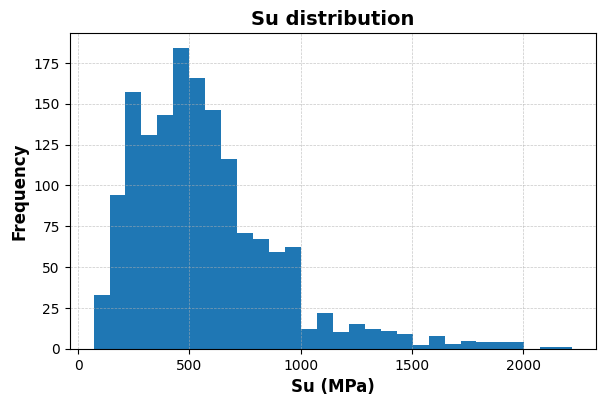

Saved: hist_Sy.png


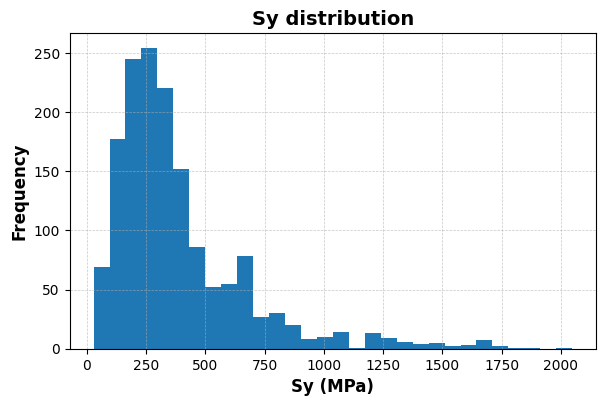

Saved: hist_E.png


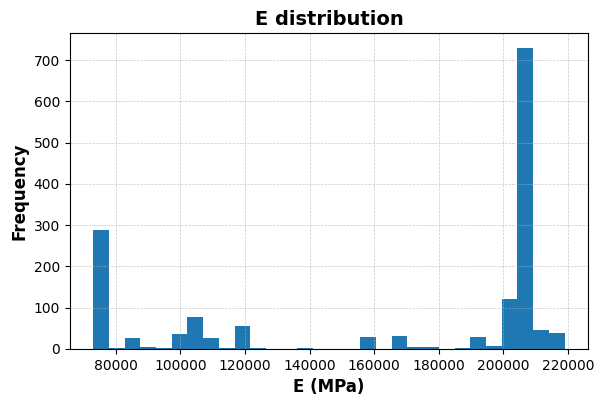

Saved: hist_G.png


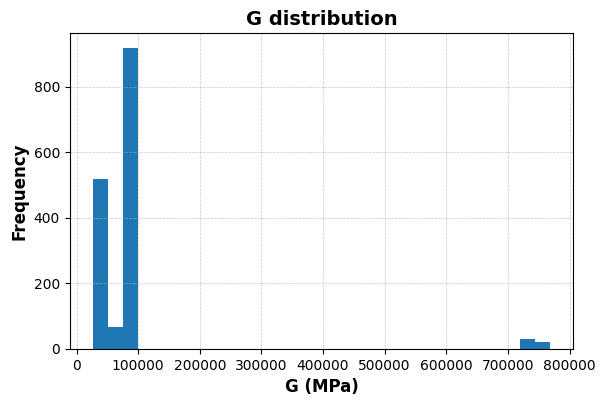

Saved: hist_mu.png


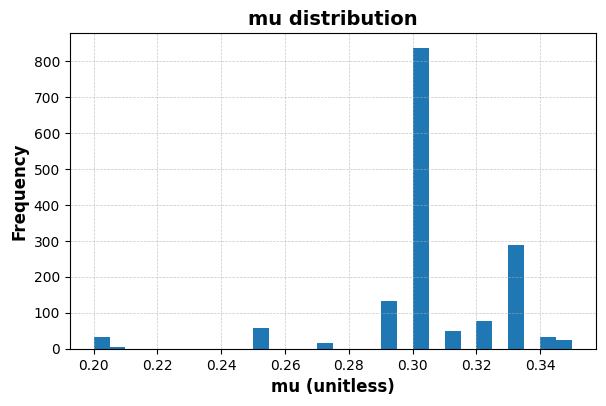

Saved: hist_Ro.png


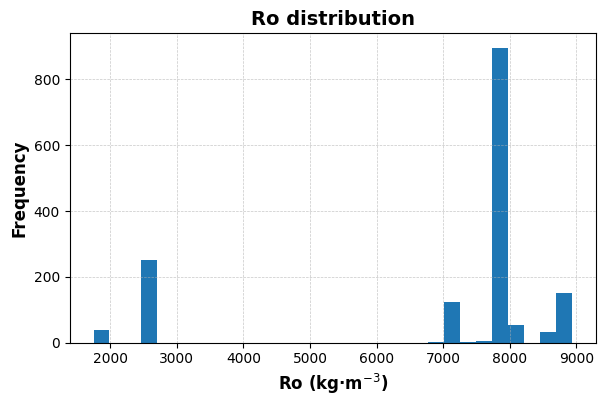

Saved: correlation_heatmap.png


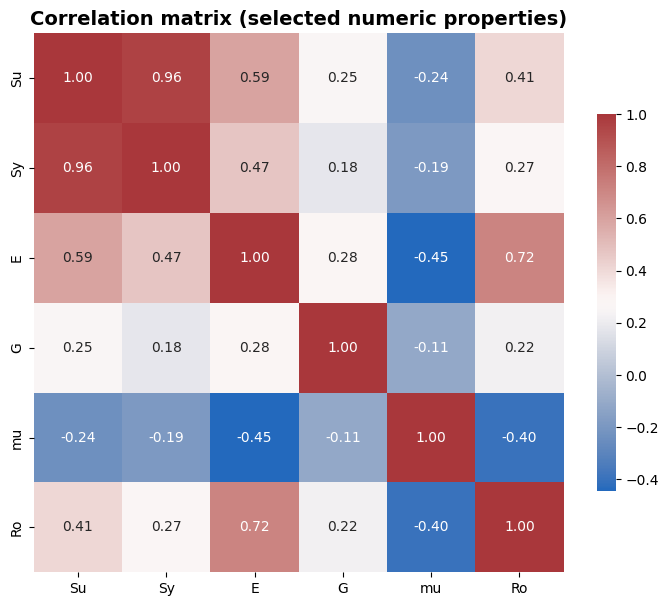

Saved: 3d_E_Su_Ro.png


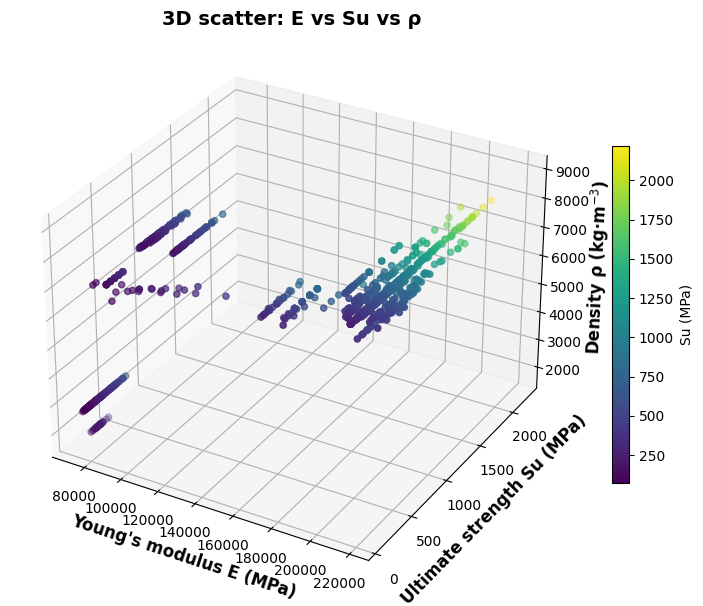

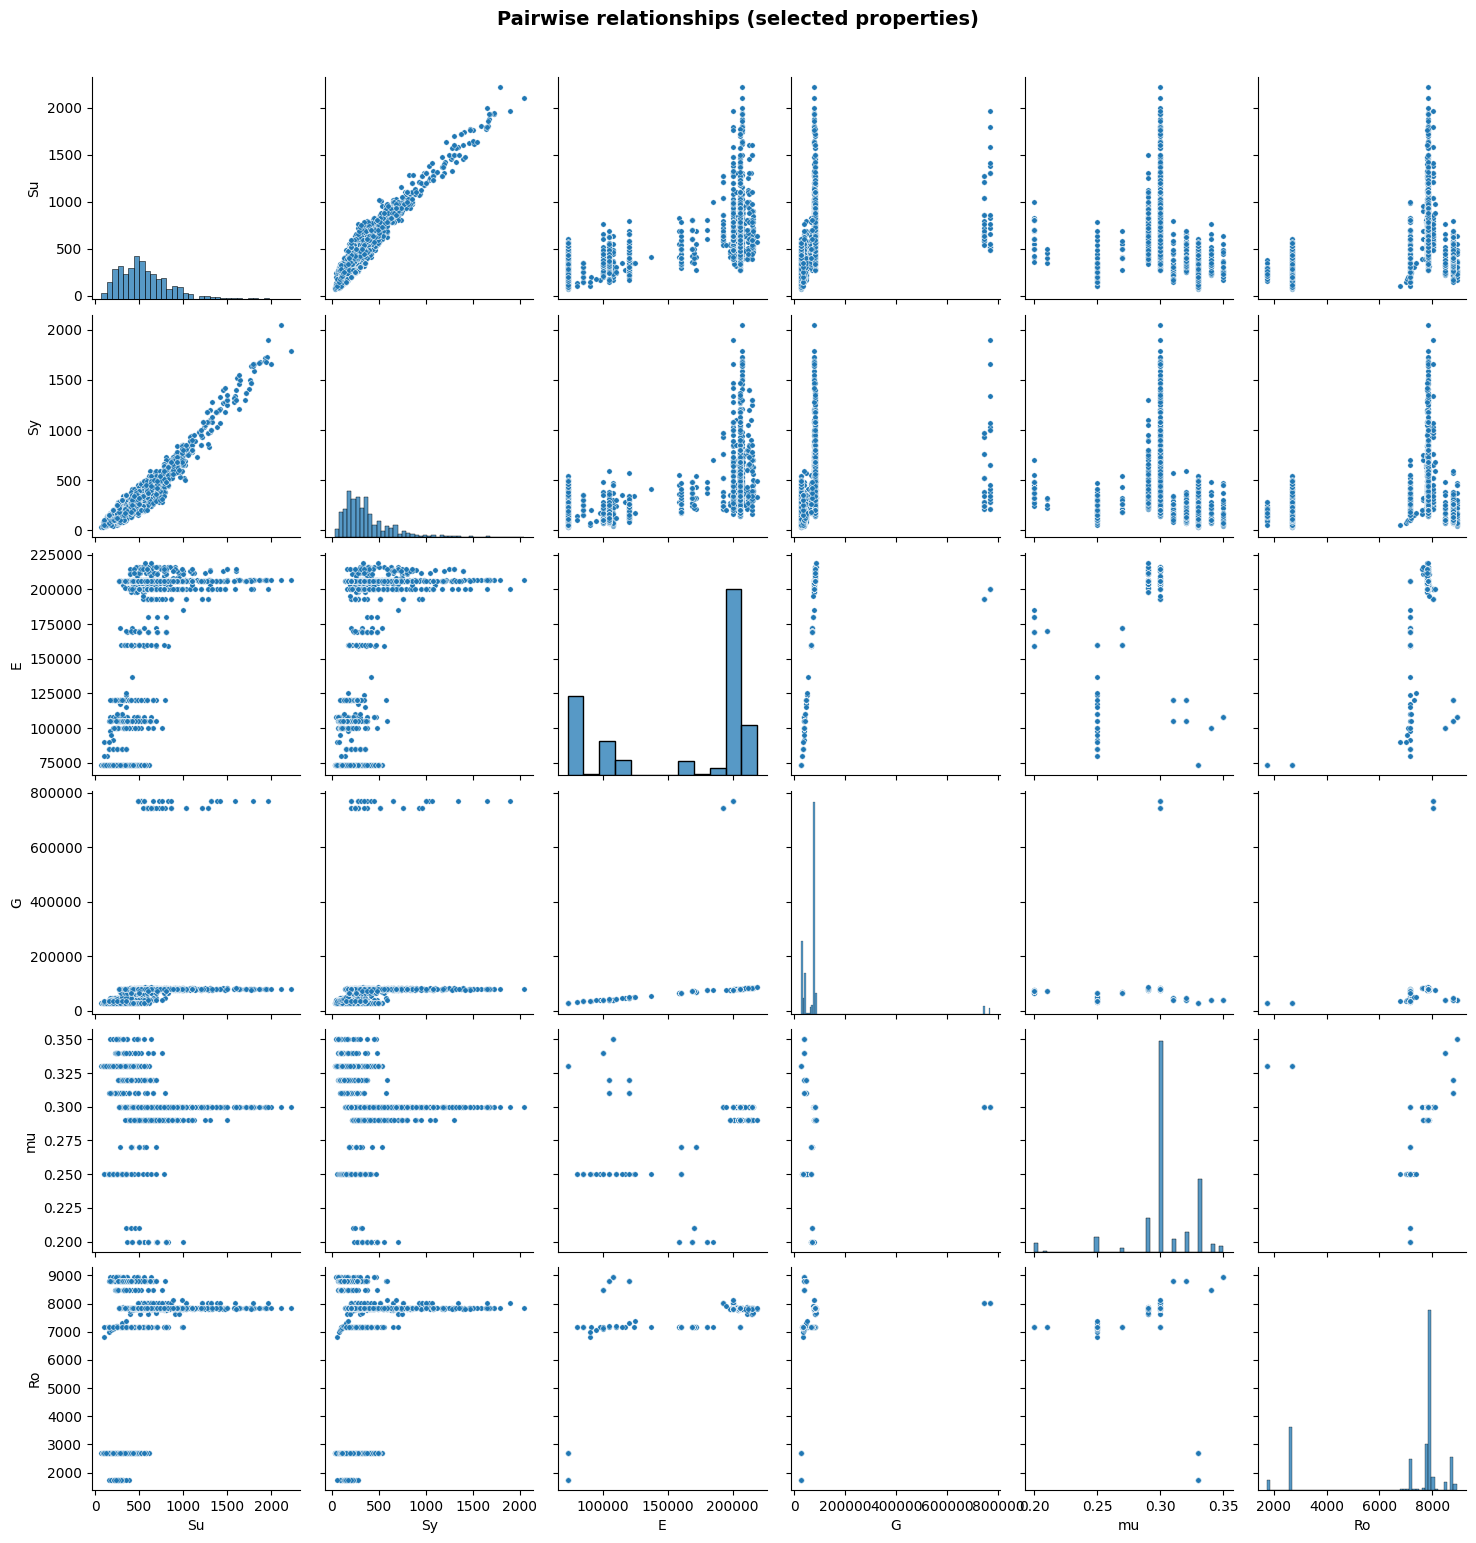

Saved: pairwise_properties.png


In [6]:
# Step 6: publication-ready visualizations
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# We will plot: histograms for numeric columns, correlation heatmap, 3D scatter (E vs Su vs Ro)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Keep the sample columns to plot
plot_cols = [c for c in ['Su','Sy','E','G','mu','Ro'] if c in numeric_cols]

# Helper for saving with IEEE formatting
def save_fig(fig, filename, dpi=900):
    fig.tight_layout(pad=0.5)
    fig.savefig(filename, dpi=dpi, bbox_inches='tight')
    print("Saved:", filename)

# 6.1 Histograms (one per figure)
for col in plot_cols:
    fig, ax = plt.subplots(figsize=(6,4))
    ax.hist(df[col].dropna(), bins=30)
    ax.set_title(f"{col} distribution", fontweight='bold', fontsize=14)
    unit = ""
    if col in ['Su','Sy']: unit = " (MPa)"
    if col in ['E','G']: unit = " (MPa)"
    if col == 'Ro': unit = " (kg·m$^{-3}$)"
    if col == 'mu': unit = " (unitless)"
    ax.set_xlabel(f"{col}{unit}", fontweight='bold', fontsize=12)
    ax.set_ylabel("Frequency", fontweight='bold', fontsize=12)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    save_fig(fig, f"hist_{col}.png", dpi=900)
    plt.show()  # ← show instead of close

# 6.2 Correlation heatmap (numerical)
corr = df[plot_cols].corr()
fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", ax=ax, cbar_kws={'shrink':0.7}, square=False)
ax.set_title("Correlation matrix (selected numeric properties)", fontweight='bold', fontsize=14)
save_fig(fig, "correlation_heatmap.png", dpi=900)
plt.show()  # ← show instead of close

# 6.3 3D scatter: E vs Su vs Ro (if all present)
if all(col in df.columns for col in ['E','Su','Ro']):
    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection='3d')
    sc = ax.scatter(df['E'], df['Su'], df['Ro'], c=df['Su'], cmap='viridis', s=20, depthshade=True)
    ax.set_xlabel('Young\'s modulus E (MPa)', fontweight='bold', fontsize=12)
    ax.set_ylabel('Ultimate strength Su (MPa)', fontweight='bold', fontsize=12)
    ax.set_zlabel('Density ρ (kg·m$^{-3}$)', fontweight='bold', fontsize=12)
    ax.set_title("3D scatter: E vs Su vs ρ", fontweight='bold', fontsize=14)
    fig.colorbar(sc, ax=ax, shrink=0.6, label='Su (MPa)')
    ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.6)
    save_fig(fig, "3d_E_Su_Ro.png", dpi=900)
    plt.show()  # ← show instead of close
else:
    print("Skipping 3D scatter: required columns missing.")

# 6.4 (optional) pairplot for visual relationships - saved high-res
if len(plot_cols) <= 6 and len(plot_cols) >= 2:
    fig = sns.pairplot(df[plot_cols].dropna(), diag_kind='hist', plot_kws={'s':15})
    fig.fig.suptitle("Pairwise relationships (selected properties)", fontsize=14, fontweight='bold', y=1.03)
    fig.savefig("pairwise_properties.png", dpi=900, bbox_inches='tight')
    plt.show()  # ← show instead of close
    print("Saved: pairwise_properties.png")

In [8]:
# Step 7: baseline regression and regression plot with R^2 annotation
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Select X and y - using processed pipeline values if proc_df exists, else raw numeric features
try:
    X_all = proc_df.drop(columns=targets).values
    feature_names = proc_df.drop(columns=targets).columns.tolist()
    print("Using processed features:", len(feature_names))
except Exception:
    # fallback: use numeric features (excluding target)
    feature_names = [c for c in df.select_dtypes(include=[np.number]).columns if c not in targets]
    X_all = df[feature_names].fillna(df[feature_names].median()).values
    print("Using raw numeric features:", feature_names)

y = df[primary_target].values

# train-test split
X_train, X_test, y_train, y_test = train_test_split(X_all, y, test_size=0.2, random_state=42)

# baseline model
model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# metrics
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
print(f"Baseline RandomForest -> R^2: {r2:.4f}, RMSE: {rmse:.4f}, MAE: {mae:.4f}")

# Regression scatter plot with regression line and perfect line
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(y_test, y_pred, s=20)
# linear regression line fit for predicted vs actual
lr = LinearRegression().fit(y_test.reshape(-1,1), y_pred)
line_x = np.linspace(min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max()), 100)
line_y = lr.predict(line_x.reshape(-1,1))
ax.plot(line_x, line_y, linestyle='-', linewidth=1.5, label='Regression fit')
# perfect prediction line
ax.plot(line_x, line_x, linestyle='--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel(f"Actual {primary_target} (MPa)", fontweight='bold', fontsize=12)
ax.set_ylabel(f"Predicted {primary_target} (MPa)", fontweight='bold', fontsize=12)
ax.set_title(f"Actual vs Predicted ({primary_target})", fontweight='bold', fontsize=14)
# R^2 annotation
ax.text(0.05, 0.95, f'$R^2$ = {r2:.4f}', transform=ax.transAxes, fontsize=12, fontweight='bold', verticalalignment='top')
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
ax.legend(loc='lower right', frameon=True)
save_fig(fig, f"actual_vs_predicted_{primary_target}.png", dpi=900)
plt.close(fig)

Using processed features: 11
Baseline RandomForest -> R^2: 0.4761, RMSE: 225.7761, MAE: 156.6638
Saved: actual_vs_predicted_Su.png


Using processed features: 11
Baseline RandomForest -> R^2: 0.4761, RMSE: 225.7761, MAE: 156.6638
Saved: actual_vs_predicted_Su.png


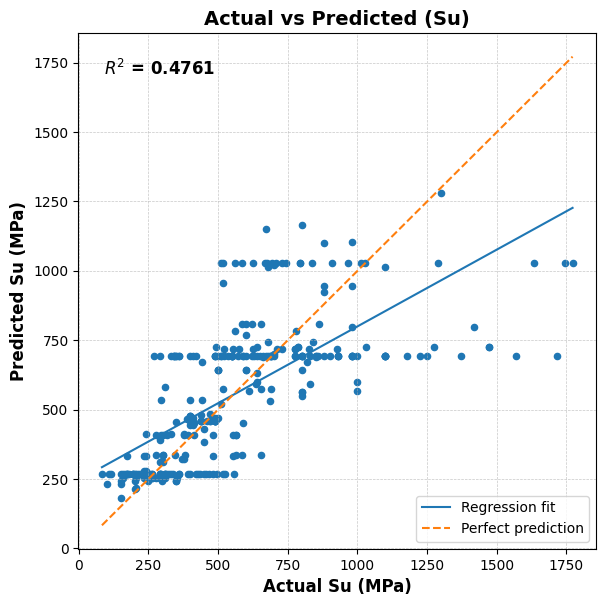

In [9]:
# Step 7: baseline regression and regression plot with R^2 annotation
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Select X and y - using processed pipeline values if proc_df exists, else raw numeric features
try:
    X_all = proc_df.drop(columns=targets).values
    feature_names = proc_df.drop(columns=targets).columns.tolist()
    print("Using processed features:", len(feature_names))
except Exception:
    # fallback: use numeric features (excluding target)
    feature_names = [c for c in df.select_dtypes(include=[np.number]).columns if c not in targets]
    X_all = df[feature_names].fillna(df[feature_names].median()).values
    print("Using raw numeric features:", feature_names)

y = df[primary_target].values

# train-test split
X_train, X_test, y_train, y_test = train_test_split(X_all, y, test_size=0.2, random_state=42)

# baseline model
model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# metrics
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
print(f"Baseline RandomForest -> R^2: {r2:.4f}, RMSE: {rmse:.4f}, MAE: {mae:.4f}")

# Regression scatter plot with regression line and perfect line
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(y_test, y_pred, s=20)
# linear regression line fit for predicted vs actual
lr = LinearRegression().fit(y_test.reshape(-1,1), y_pred)
line_x = np.linspace(min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max()), 100)
line_y = lr.predict(line_x.reshape(-1,1))
ax.plot(line_x, line_y, linestyle='-', linewidth=1.5, label='Regression fit')
# perfect prediction line
ax.plot(line_x, line_x, linestyle='--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel(f"Actual {primary_target} (MPa)", fontweight='bold', fontsize=12)
ax.set_ylabel(f"Predicted {primary_target} (MPa)", fontweight='bold', fontsize=12)
ax.set_title(f"Actual vs Predicted ({primary_target})", fontweight='bold', fontsize=14)
# R^2 annotation
ax.text(0.05, 0.95, f'$R^2$ = {r2:.4f}', transform=ax.transAxes, fontsize=12, fontweight='bold', verticalalignment='top')
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
ax.legend(loc='lower right', frameon=True)

# Save and show the figure
save_fig(fig, f"actual_vs_predicted_{primary_target}.png", dpi=900)
plt.show()  # <-- show instead of close